<a href="https://colab.research.google.com/github/herrezueloangel/especialidad-analisis-datos/blob/main/SPRINT%209/SPRINT_9_BIG_QUERY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**SPRINT 9**

## **Nivell 1 - Visualització analítica guiada en Python**

## Exercici 1: Preguntes analítiques directes (sense integracions complexes)

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()
client = bigquery.Client(project='sprint3-analytics-aherrezuelo')

### Pregunta 1 - Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.


In [128]:
transactions = client.query("""
    SELECT * FROM `sprint3-analytics-aherrezuelo.sprint3_bronze.transactions_raw`
""").to_dataframe()

In [129]:
transactions.head()


,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude
0,3F614E9B-1EEC-4FB7-8B88-ABCD6C519EED,CcS-8216,b-2526,2019-08-18 21:09:25+00:00,207.52,0,"69, 97, 31",3635,33.458167,-112.082896
1,44CD5F49-4D07-4E8C-B87E-DE51EB730676,CcS-6410,b-2422,2015-05-29 03:12:04+00:00,568.34,0,"7, 64, 16, 34",1829,46.812519,-71.215955
2,116544E8-A709-4950-B5E4-0E7752AD65DF,CcU-4681,b-2242,2018-08-17 03:10:01+00:00,195.62,0,64,26,39.951970,-75.160029
3,EA185F4E-B0D7-4147-9D2B-C280E1703C57,CcU-3442,b-2490,2020-10-01 03:00:26+00:00,103.73,0,71,203,46.804142,-71.198762
4,557A345F-931A-4EEB-95BD-616953B21FA4,CcS-7870,b-2338,2024-11-10 14:09:50+00:00,302.84,0,"31, 73, 71",3289,45.420348,-75.692861


In [130]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype              
---  ------       --------------   -----              
 0   id           100000 non-null  object             
 1   card_id      100000 non-null  object             
 2   business_id  100000 non-null  object             
 3   timestamp    100000 non-null  datetime64[us, UTC]
 4   amount       100000 non-null  float64            
 5   declined     100000 non-null  Int64              
 6   product_ids  100000 non-null  object             
 7   user_id      100000 non-null  Int64              
 8   lat          100000 non-null  float64            
 9   longitude    100000 non-null  float64            
dtypes: Int64(2), datetime64[us, UTC](1), float64(3), object(4)
memory usage: 7.8+ MB


Se crea una columna de fecha usando el normalize para Python trate esta columna como un datetime y podamos operar con ella.

In [131]:
transactions['fecha'] = pd.to_datetime(transactions['timestamp']).dt.normalize()

In [132]:
transactions.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,fecha
0,3F614E9B-1EEC-4FB7-8B88-ABCD6C519EED,CcS-8216,b-2526,2019-08-18 21:09:25+00:00,207.52,0,"69, 97, 31",3635,33.458167,-112.082896,2019-08-18 00:00:00+00:00
1,44CD5F49-4D07-4E8C-B87E-DE51EB730676,CcS-6410,b-2422,2015-05-29 03:12:04+00:00,568.34,0,"7, 64, 16, 34",1829,46.812519,-71.215955,2015-05-29 00:00:00+00:00
2,116544E8-A709-4950-B5E4-0E7752AD65DF,CcU-4681,b-2242,2018-08-17 03:10:01+00:00,195.62,0,64,26,39.951970,-75.160029,2018-08-17 00:00:00+00:00
3,EA185F4E-B0D7-4147-9D2B-C280E1703C57,CcU-3442,b-2490,2020-10-01 03:00:26+00:00,103.73,0,71,203,46.804142,-71.198762,2020-10-01 00:00:00+00:00
4,557A345F-931A-4EEB-95BD-616953B21FA4,CcS-7870,b-2338,2024-11-10 14:09:50+00:00,302.84,0,"31, 73, 71",3289,45.420348,-75.692861,2024-11-10 00:00:00+00:00


He creado una columna con mes y otra con año, así se a la hora de visualizar podemos ver cada año en una misma linea y ver la evolución de ventas durante año.

In [133]:
transactions['año'] = transactions['fecha'].dt.year
transactions['mes'] = transactions['fecha'].dt.month

Calculamos la evolución de la transacciones agrupadas por dos variables, año y mes. Usamos el .unstack para pasar de formato largo a formato ancho (en este caso se dicel level=0, convertimos el año en columna y el mes como índice), lo que permite dibujar una línea por año. De no usarlo, dibujaría una sola linea, desde el año más lejano, veriamos la evolución durante el año y seguido el siguiente año.

In [134]:
evolucion = transactions.groupby(['año','mes'])['id'].count().unstack(level=0)

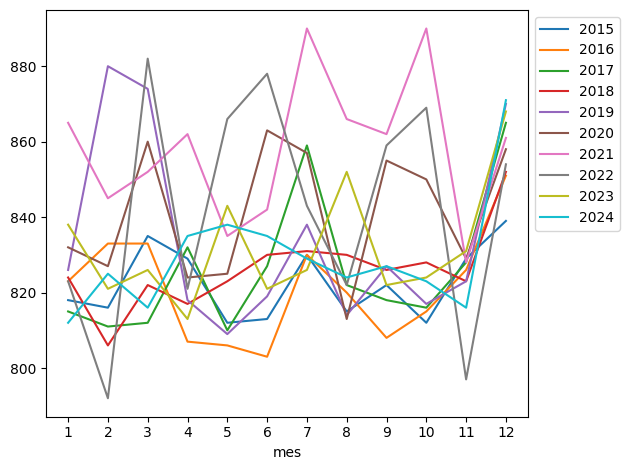

In [135]:
evolucion.plot()
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.xticks(range(1,13))
plt.show()

###**Conclusión:**
Tras visualizar el gráfico de linea podemos observar:
- Las ventas no tienen una estacionalidad. Cada año y cada mes se comportan de manera diferente a excepción de Diciembre, donde claramente vemos estacionalidad porque todos los años las ventas suben ese mes.
- 2021, vemos que hay un incremento reseñable de las ventas, puede ser debido al COVID. Más gente compraba online.


###**IA**

**Prompt:** Tengo un DataFrame con transacciones. He creado un gráfico de líneas con una línea por año y los meses en el eje X para ver la evolución. ¿Qué visualización alternativa me propones para analizar la evolución temporal de transacciones? Dame el código en Python.

**Propuesta de Gemini:** Un **heatmap** es una excelente manera de visualizar la evolución temporal de las transacciones. Permite ver la intensidad de la actividad (número de transacciones) para cada mes a lo largo de los años mediante una escala de colores. Esto facilita la identificación de patrones estacionales, tendencias anuales y cualquier mes con actividad inusualmente alta o baja.

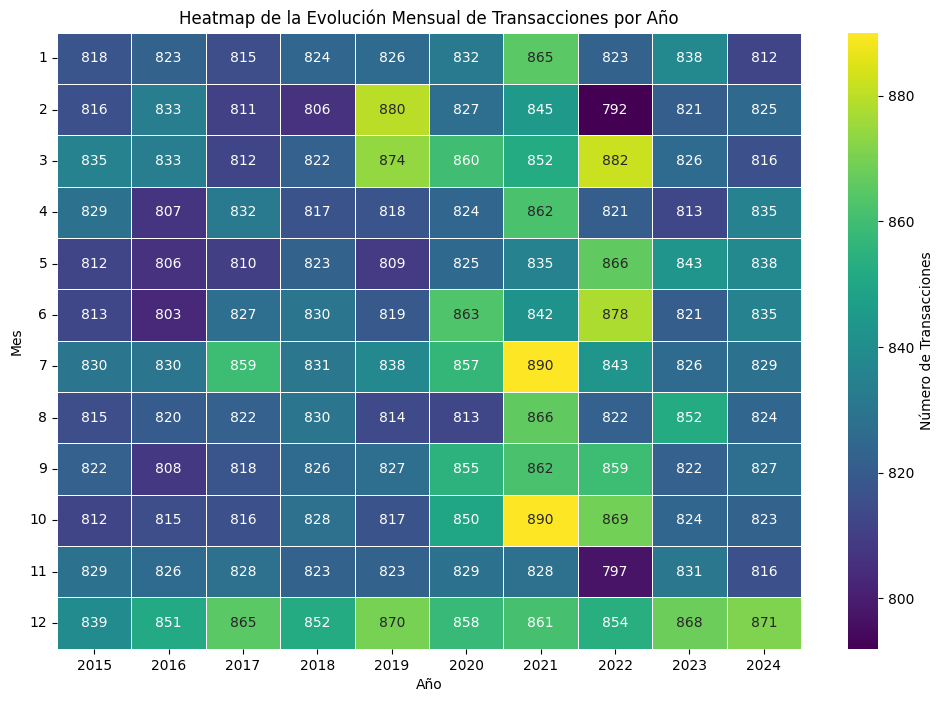

In [136]:
plt.figure(figsize=(12, 8))
sns.heatmap(evolucion, cmap='viridis', annot=True, fmt='g', linewidths=.5, cbar_kws={'label': 'Número de Transacciones'})
plt.title('Heatmap de la Evolución Mensual de Transacciones por Año')
plt.xlabel('Año')
plt.ylabel('Mes')
plt.yticks(rotation=0)
plt.show()

**Conclusión:**

El gráfico de *heatmap* es más visual, es más efectivo para ver extremos y sucesos puntuales. El gráfico de lineas facilita el visualizar tendencias, comparar la evolución.

###Pregunta 2 - Quins usuaris generen més volum de facturació?

Sumame las ventas, agrúpalas por user id, pero solo aquellas transacciones que no han sido declined.
Muestra el resultado de los 15 primeros con mas ventas.

BigQuery puede importar la columna 'declines' como string, lo pasamos a int.

In [137]:
transactions['declined'] = transactions['declined'].astype(int)

mas_transactions = (
    transactions[transactions['declined'] == 0]
    .groupby('user_id')['amount']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

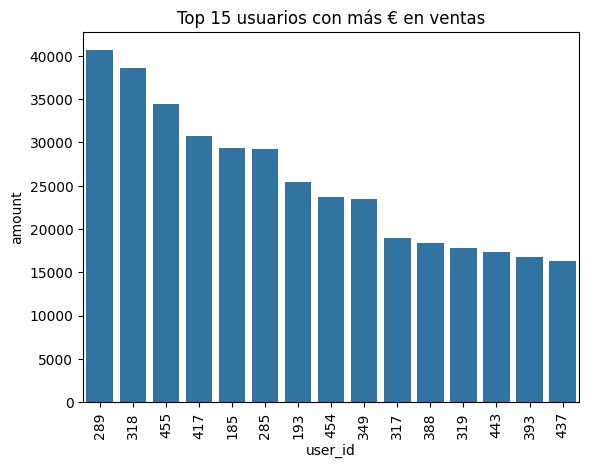

In [138]:
sns.barplot(data=mas_transactions, x="user_id", y="amount", order=mas_transactions.sort_values("amount", ascending=False).user_id)
plt.xticks(rotation=90)
plt.title('Top 15 usuarios con más € en ventas')
plt.show()

###**IA**

**Prompt:** Tengo un barplot de Seaborn con los 15 usuarios con más volumen de facturación. ¿Qué visualización alternativa me propones para mostrar este ranking de usuarios? Dame el código en Python.

**Propuesta Gemini:** Una lollipop chart (gráfico de piruleta) es una excelente alternativa para visualizar rankings de datos. Es similar a un gráfico de barras, pero utiliza un punto en lugar de una barra completa, lo que a menudo reduce el desorden visual, especialmente cuando hay muchas categorías. Permite resaltar tanto la posición en el ranking como el valor exacto de cada elemento.

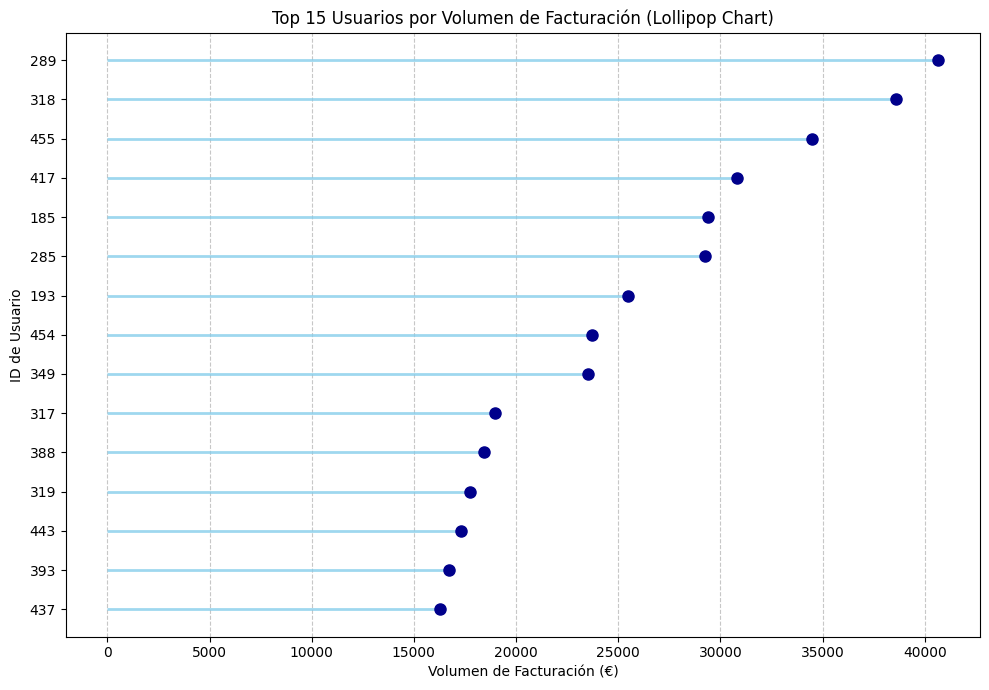

In [139]:
plt.figure(figsize=(10, 7))

# Sort the DataFrame for better visualization
mas_transactions_sorted = mas_transactions.sort_values('amount', ascending=True)

# Create the lollipop chart
plt.hlines(y=mas_transactions_sorted['user_id'].astype(str), xmin=0, xmax=mas_transactions_sorted['amount'], color='skyblue', alpha=0.8, linewidth=2)
plt.plot(mas_transactions_sorted['amount'], mas_transactions_sorted['user_id'].astype(str), "o", color='darkblue', markersize=8)

plt.title('Top 15 Usuarios por Volumen de Facturación (Lollipop Chart)')
plt.xlabel('Volumen de Facturación (€)')
plt.ylabel('ID de Usuario')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###**Conclusión**:

Ambos gráficos son bastante parecidos en legibilidad. El lollipop como que se ve más limpio, menor ruido visual. Para un ranking de 15 está bien ambos, pero si el ranking fuese mayor número de 'ids', el de columnas sería más intuitivo, fácil de leer y comparar.

###Pregunta 3 - Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades?

In [140]:
transactions['hora'] = pd.to_datetime(transactions['timestamp']).dt.hour

La tasa de operaciones rechazadas no parece estar relacionada con el importe.
Hay anomalías en los datos con valores negativos.Hay transacciones con importe negativo, ¿son devoluciones?

<Axes: xlabel='hora', ylabel='amount'>

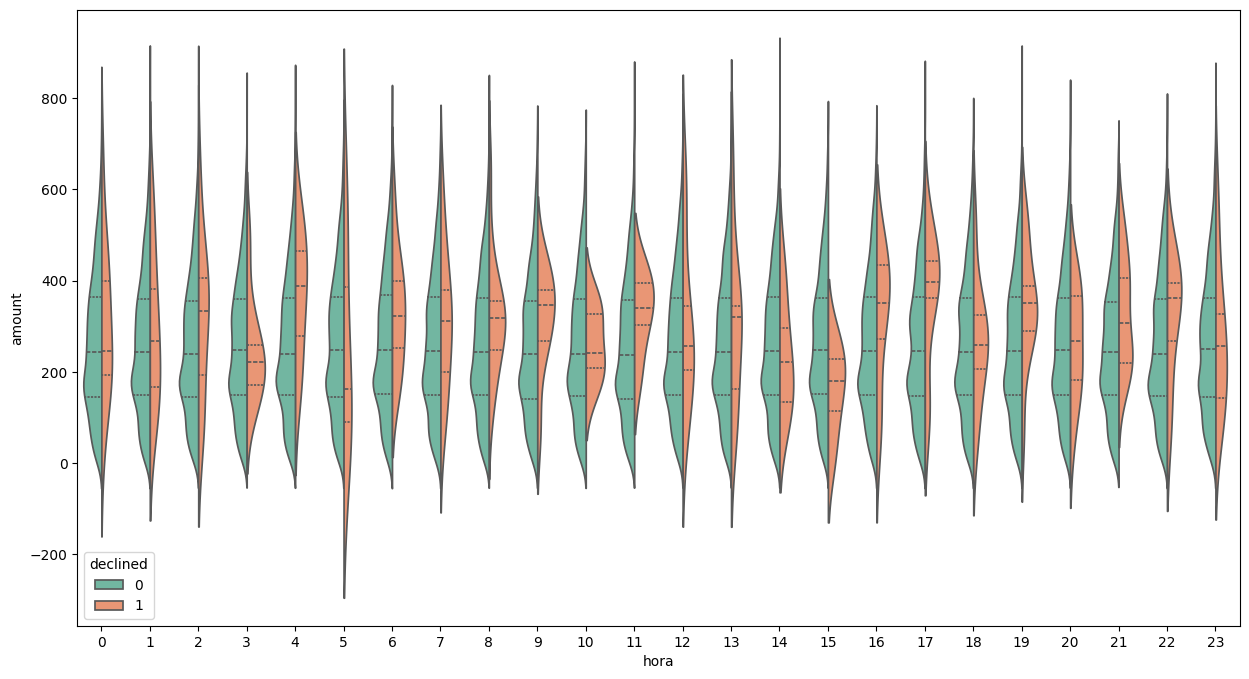

In [141]:
plt.figure(figsize=(15, 8))
sns.violinplot(data=transactions, x="hora", y="amount", palette="Set2", hue="declined",
               inner="quartile",
               split=True)

###**IA**

**Prompt:** Tengo un violinplot con la distribución del importe de transacciones por hora del día, separando aceptadas y rechazadas con hue. ¿Qué visualización alternativa me propones para analizar esta misma pregunta? Dame el código en Python.

**Propuesta Gemini:** Un **box plot** es una excelente alternativa al violin plot para comparar la distribución de importes de transacciones por hora del día y estado de declinación. Ofrece una vista más concisa de la mediana, los cuartiles y los valores atípicos, lo que facilita la comparación entre las 24 horas y los dos estados (aceptado/rechazado). Es particularmente útil para identificar rápidamente la dispersión y la tendencia central de los datos en cada grupo.


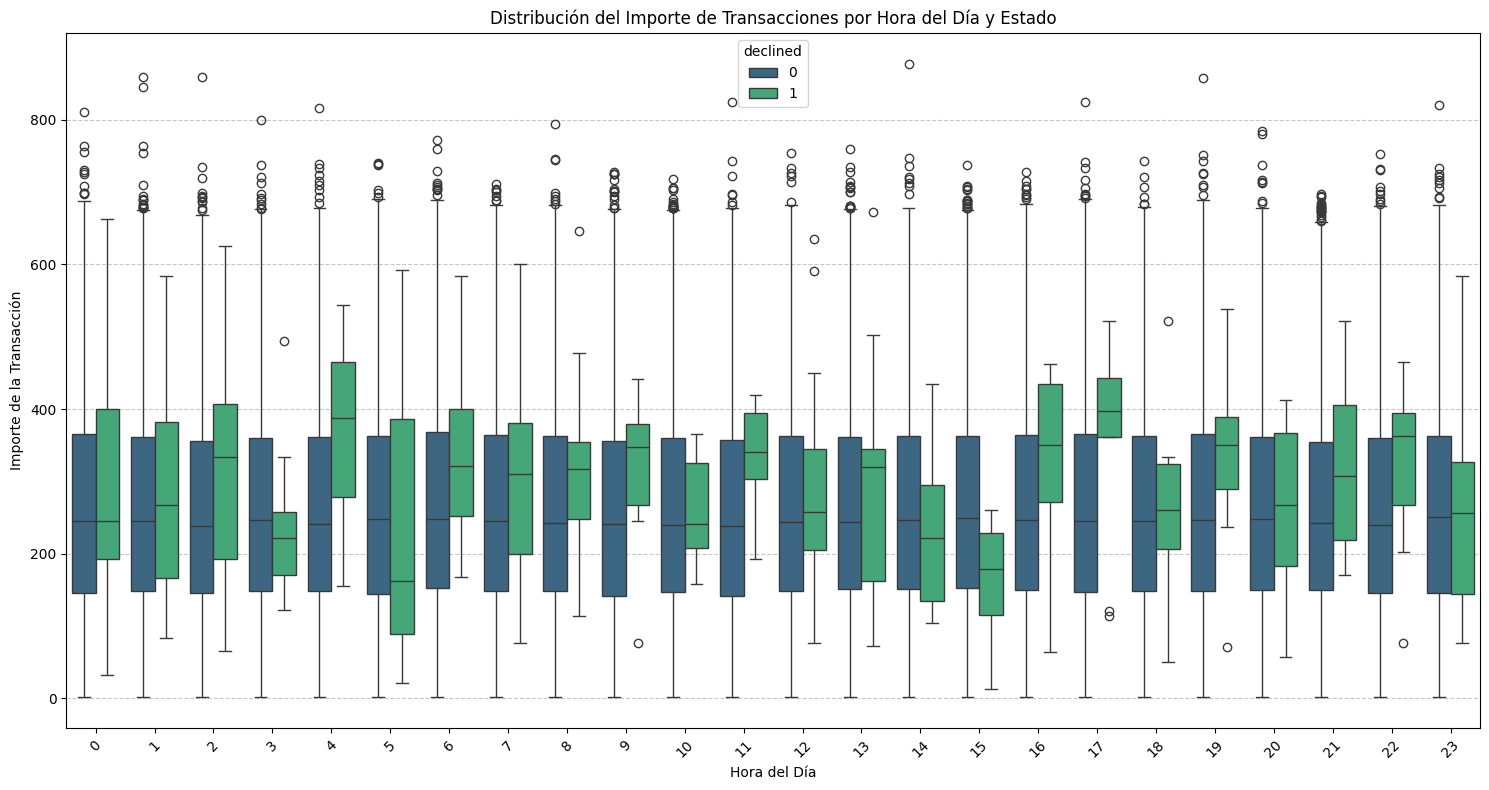

In [142]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=transactions, x="hora", y="amount", hue="declined", palette="viridis")
plt.title('Distribución del Importe de Transacciones por Hora del Día y Estado')
plt.xlabel('Hora del Día')
plt.ylabel('Importe de la Transacción')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###**Conclusión:**

Una de las ventajas del gráfico *violinplot*, es la visualización del grosor de la frecuencia de las transacciones, tanto efectuadas como rechazadas. Podemos ver además, es visualmente más fácil detectar los picos, el groso de operaciones según el importe.

El gráfico boxplot, es más exacto, ya que nos muestra medidas exactas como los cuartiles, mínimos o máximos. También es más claro a la hora de mostrarnos los outliers.

###Pregunta 4 - Quins dies de la setmana es concentra més activitat de venda?

Se crea una columna con el día de la semana en número.
Se crea un diccionario que hace como de traductor, si en la celda ves un 0, es igual a 'Lunes'.
Por último, se crea una nueva columna con esta traducción de número de día de la semana por nombre de día de la semana, gracias a .map() python va fila por fila y cuando ve un número, escribe el nombre del día.

In [143]:
transactions['dia_numero'] = transactions['fecha'].dt.dayofweek

nombres_dias = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

transactions['dia_nombre'] = transactions['fecha'].dt.dayofweek.map(nombres_dias)


Filtramos las trasacciones por operaciones no rechazadas, agrupamos por las dos columnas. contamos el numero de transacciones por dia, ordenamos de lunes a domingo (sort_index),

In [144]:
ventas_dias = transactions[transactions['declined'] == 0].groupby(['dia_numero','dia_nombre'])['id'].count().sort_index(level='dia_numero',ascending=True).reset_index()

In [145]:
ventas_dias

,dia_numero,dia_nombre,id
0,0,Lunes,14088
1,1,Martes,14140
2,2,Miércoles,14242
3,3,Jueves,14485
4,4,Viernes,14232
5,5,Sábado,14314
6,6,Domingo,14262


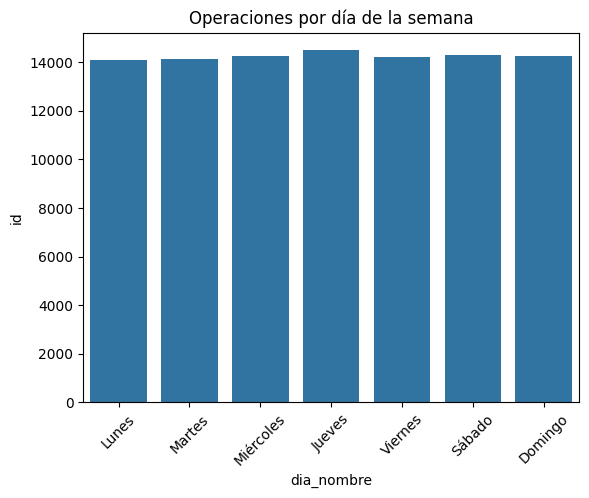

In [146]:
sns.barplot(data=ventas_dias, x="dia_nombre", y="id", order=ventas_dias.sort_values(by='dia_numero',ascending=True)['dia_nombre'])
plt.xticks(rotation=45)
plt.title('Operaciones por día de la semana')
plt.show()

###**IA**

**Prompt:** Tengo un barplot con el número de transacciones por día de la semana ordenado de lunes a domingo. ¿Qué visualización alternativa me propones? Dame el código en Python.

**Propuesta Gemini:** Un **gráfico de barras radial** es una alternativa visualmente atractiva y efectiva para representar datos categóricos con una naturaleza cíclica, como los días de la semana. En lugar de barras rectilíneas, las barras se extienden desde el centro de un círculo hacia afuera, con cada segmento representando un día de la semana. Esto ayuda a visualizar la distribución de la actividad a lo largo de la semana de una manera que destaca la continuidad y los patrones.

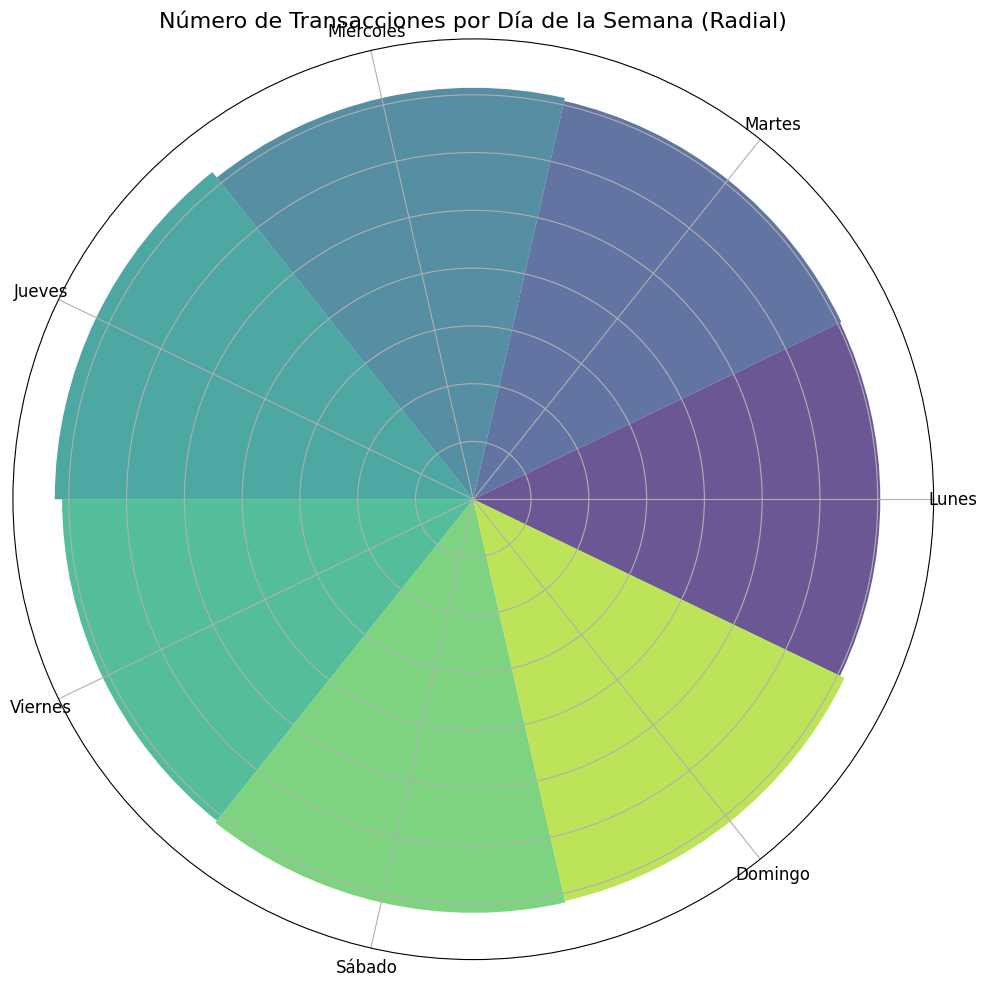

In [147]:
import numpy as np

# Ensure ventas_dias is sorted by dia_numero (Monday=0 to Sunday=6)
ventas_dias_sorted = ventas_dias.sort_values(by='dia_numero', ascending=True).reset_index(drop=True)

# Number of days
num_days = len(ventas_dias_sorted)

# Calculate angles for each bar
angles = np.linspace(0, 2 * np.pi, num_days, endpoint=False)

# Create a polar plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

# Plot bars
bars = ax.bar(angles, ventas_dias_sorted['id'], width=2 * np.pi / num_days, bottom=0, color=sns.color_palette('viridis', num_days), alpha=0.8)

# Add labels for each day
ax.set_xticks(angles)
ax.set_xticklabels(ventas_dias_sorted['dia_nombre'], fontsize=12)

# Set y-axis limits and labels
ax.set_ylim(0, ventas_dias_sorted['id'].max() * 1.1) # Give some padding
ax.set_yticklabels([]) # Hide radial ticks, as they can be distracting

# Add a title
ax.set_title('Número de Transacciones por Día de la Semana (Radial)', va='bottom', fontsize=16)

# Display the plot
plt.tight_layout()
plt.show()

###**Conclusión:**

El gráfico radial visualmente es muy atractivo, pero no ayuda la visualización de los datos. Es más complejo comparar los resultados.
La diferencia que hay en las cifras es tan mínima que este tipo de gráfico no ayuda a que se pueda apreciar la diferencia.

##**Exercici 2: Preguntes analítiques complexes (amb guia)**

### Pregunta 1: Depenem excessivament d'un nombre reduït de països de companyies venedores?


In [148]:
companies = client.query("""
    SELECT * FROM `sprint3-analytics-aherrezuelo.sprint3_bronze.companies_raw`
""").to_dataframe()

companies.head(5)

,id,name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings


Combinar la informació de transaccions amb la de companyies

In [149]:
resultado = transactions.merge(companies, left_on='business_id', right_on='id', how='left')

resultado

,id_x,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,mes,hora,dia_numero,dia_nombre,id_y,name,phone,email,country,website
0,3F614E9B-1EEC-4FB7-8B88-ABCD6C519EED,CcS-8216,b-2526,2019-08-18 21:09:25+00:00,207.52,0,"69, 97, 31",3635,33.458167,-112.082896,...,8,21,6,Domingo,b-2526,Amet Luctus Vulputate Foundation,03 18 54 24 19,nulla@outlook.com,Canada,https://netflix.com/en-ca
1,44CD5F49-4D07-4E8C-B87E-DE51EB730676,CcS-6410,b-2422,2015-05-29 03:12:04+00:00,568.34,0,"7, 64, 16, 34",1829,46.812519,-71.215955,...,5,3,4,Viernes,b-2422,Urna Convallis Associates,06 01 24 77 04,aliquam@yahoo.org,United States,https://cnn.com/sub/cars
2,116544E8-A709-4950-B5E4-0E7752AD65DF,CcU-4681,b-2242,2018-08-17 03:10:01+00:00,195.62,0,64,26,39.951970,-75.160029,...,8,3,4,Viernes,b-2242,Donec Ltd,01 25 51 37 37,at.iaculis@hotmail.couk,Norway,https://nytimes.com/user/110
3,EA185F4E-B0D7-4147-9D2B-C280E1703C57,CcU-3442,b-2490,2020-10-01 03:00:26+00:00,103.73,0,71,203,46.804142,-71.198762,...,10,3,3,Jueves,b-2490,Nunc Sit Incorporated,07 28 42 63 63,pede.ultrices@icloud.net,Norway,https://naver.com/en-ca
4,557A345F-931A-4EEB-95BD-616953B21FA4,CcS-7870,b-2338,2024-11-10 14:09:50+00:00,302.84,0,"31, 73, 71",3289,45.420348,-75.692861,...,11,14,6,Domingo,b-2338,Magna Incorporated,07 73 69 44 18,non@google.net,New Zealand,https://twitter.com/en-us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,4C3788F0-D96A-4635-B7DC-5EB6D7FCFECC,CcS-6993,b-2618,2020-10-05 00:49:19+00:00,37.04,0,"51, 95",2412,52.064330,4.293265,...,10,0,0,Lunes,b-2618,Non Institute,06 77 15 31 14,amet.metus@protonmail.couk,United Kingdom,https://guardian.co.uk/settings
99996,1120A5F9-ED16-4398-86CF-9E0AE9C2BF91,CcS-8075,b-2618,2020-08-28 23:05:58+00:00,328.58,0,"98, 4, 1, 69",3494,48.863920,2.355724,...,8,23,4,Viernes,b-2618,Non Institute,06 77 15 31 14,amet.metus@protonmail.couk,United Kingdom,https://guardian.co.uk/settings
99997,C7E7648B-CC07-47C1-A562-CC01EEFF0FC5,CcS-5950,b-2618,2024-02-15 08:47:18+00:00,324.43,0,"38, 93, 9",1369,51.582916,18.697638,...,2,8,3,Jueves,b-2618,Non Institute,06 77 15 31 14,amet.metus@protonmail.couk,United Kingdom,https://guardian.co.uk/settings
99998,7EC83904-432D-482C-BCF7-032C4E266948,CcS-6826,b-2618,2024-07-05 17:23:14+00:00,63.63,0,"55, 43",2245,55.460599,-3.289603,...,7,17,4,Viernes,b-2618,Non Institute,06 77 15 31 14,amet.metus@protonmail.couk,United Kingdom,https://guardian.co.uk/settings


Se agrupa la facturación por país, ordenado por facturación de mayor a menor.

In [150]:
por_pais = resultado.groupby('country')['amount'].sum().sort_values(ascending=False).reset_index()

por_pais

,country,amount
0,Sweden,4251072.86
1,Netherlands,3890755.90
2,United Kingdom,3537120.34
3,Italy,3530071.81
4,Germany,3466842.93
5,France,1221902.17
6,United States,1069450.71
7,Belgium,922131.39
8,Norway,785907.27
9,Ireland,693054.42


Porcentaje que representa cada país sobre el total.
Se calcula el porcentaje acumulado, permite detectar qué países acumulan el 80% de la facturación

In [151]:
por_pais['porcentaje'] = por_pais['amount'] / por_pais['amount'].sum() * 100
por_pais['porcentaje_acumulado'] = por_pais['porcentaje'].cumsum()

por_pais

,country,amount,porcentaje,porcentaje_acumulado
0,Sweden,4251072.86,16.412438,16.412438
1,Netherlands,3890755.90,15.021336,31.433774
2,United Kingdom,3537120.34,13.656028,45.089802
3,Italy,3530071.81,13.628815,58.718617
4,Germany,3466842.93,13.384703,72.103320
5,France,1221902.17,4.717490,76.820810
6,United States,1069450.71,4.128909,80.949719
7,Belgium,922131.39,3.560142,84.509861
8,Norway,785907.27,3.034212,87.544073
9,Ireland,693054.42,2.675728,90.219801


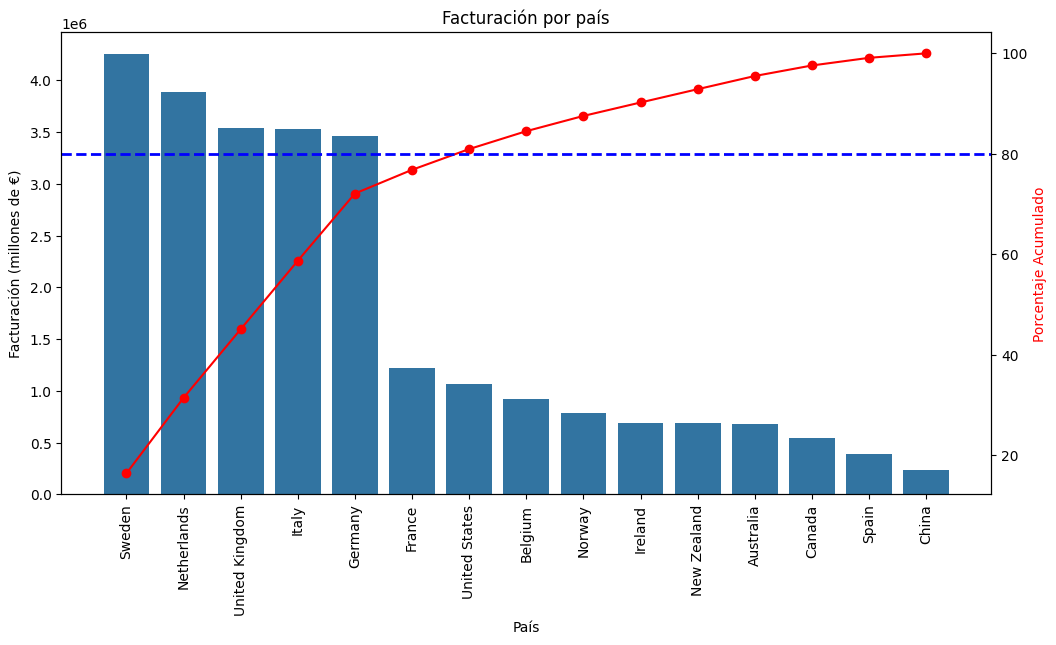

In [152]:
#5 Visualitzar

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.xticks(rotation=90)
plt.title('Facturación por país')

sns.barplot(data=por_pais, x='country', y='amount', ax=ax1)
ax1.set_ylabel('Facturación (millones de €)', color='black')
ax1.set_xlabel('País')

ax2 = ax1.twinx()
ax2.plot(por_pais['country'], por_pais['porcentaje_acumulado'], color='red', marker='o', linestyle='-', label='Porcentaje Acumulado')
ax2.set_ylabel('Porcentaje Acumulado', color='red')
ax2.axhline(y=80, color='blue', linestyle='--', linewidth=2)


### **Conclusión:**
La facturacion se encuentra relativamente distribuida entre varios países, no se observa una dependencia excesiva por un reducido número de países o mercados.
Aunque no existe una dependencia extrema de uno o dos países si que podemos observar una concentración signifivativa en los cinco primeros países. Esto podría implicar que cambios económicos en estos países podrían tener impacto en nuestra facturación.

### Pregunta 2: Existeix estacionalitat en les vendes?

Creamos una pivot table para si existe estacionalidad de forma más cómoda.

In [153]:
pivot_estacionalidad = transactions.pivot_table(
    values='amount',
    index='mes',
    columns='año',
    aggfunc='sum'
)

pivot_estacionalidad

año,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
mes,,,,,,,,,,
1,208460.24,212357.82,209339.50,214646.54,210813.99,219397.63,232197.63,212873.78,218300.84,213306.61
2,211179.56,214708.37,215198.48,209918.88,222423.06,211273.68,219685.97,202945.83,214480.16,214826.07
3,221488.19,215368.86,208608.27,207377.32,243592.36,227262.89,220554.92,238293.06,212086.80,215896.22
4,214675.51,210019.54,218995.78,205562.05,212679.25,213422.08,227276.44,209160.91,214159.74,212718.45
5,215691.13,208713.77,204784.10,210126.23,208853.84,216073.84,206925.66,236573.86,225828.47,218842.78
6,207759.31,208534.96,216287.92,217047.48,220443.02,212762.98,211362.56,233213.16,210788.42,222297.43
7,218137.92,213505.12,218788.44,208823.33,211037.50,217751.47,227301.53,211532.08,215904.46,208427.29
8,214170.06,212853.75,209566.97,207536.16,215470.42,210762.54,214414.67,220744.50,214257.04,214924.40
9,204305.09,217441.50,211802.81,214016.87,210429.63,231158.60,222361.90,228802.26,213400.04,212523.25


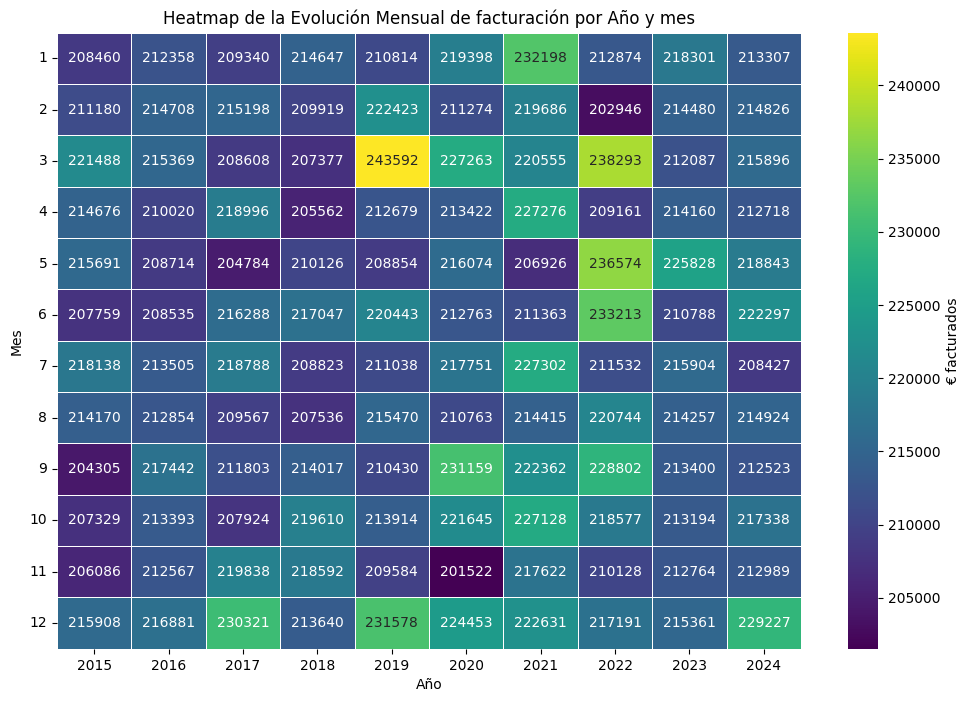

In [154]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_estacionalidad, cmap='viridis', annot=True, fmt='g', linewidths=.5, cbar_kws={'label': '€ facturados'})
plt.title('Heatmap de la Evolución Mensual de facturación por Año y mes')
plt.xlabel('Año')
plt.ylabel('Mes')
plt.yticks(rotation=0)
plt.show()

###**Conclusión**

No se observa estacionalidad significativa, la facturación es bastante homogénea durante todos los meses y años. Los picos puntuales de facturación no siguen un patrón. Por lo que no tendría sentido invertir en campañas específicas o no habría que asegurarse más stock porque la venta se centre en un momento del año como podría ser la navidad.



### Pregunta 3 - Opción A: Anàlisi de concentració i variabilitat (tria UNA opció)

In [155]:
products = client.query("""
    SELECT * FROM `sprint3-analytics-aherrezuelo.sprint3_bronze.products_raw`
""").to_dataframe()


In [156]:
products

,id,product_name,price,colour,weight,warehouse_id
0,7,north of Casterly,63.33,#b7b7b7,0.6,WH--2
1,19,dooku solo,60.33,#3f3f3f,0.6,WH--14
2,31,Lannister,85.02,#3f3f3f,0.6,WH--26
3,43,duel,59.80,#5b5b5b,0.6,WH--38
4,55,Tully maester,3.83,#6d6d6d,0.6,WH--50
...,...,...,...,...,...,...
95,41,Lannister Barratheon Direwolf,141.01,#fcfcfc,3.2,WH--36
96,53,kingsblood Littlefinger the,137.81,#3a3a3a,3.2,WH--48
97,65,riverlands the,121.91,#6b6b6b,3.2,WH--60
98,77,Tarly Littlefinger,150.50,#f4f4f4,3.2,WH--72


La columna product_ids contiene multiples ids separados por coma en cada celda,
Se convierte el texto en una lista.

In [157]:
transactions['product_ids'] = transactions['product_ids'].str.split(',')

Con explode se separa la lista en el número de valores de ids que contiene la lista de products_ids. Si una fila tiene la lista de ids de productos [52,4,21], se convertirá en 3 filas, cada fila con un valor.

Se eliminan los posibles espacios de los ids y se cambio el tipo a entero.

In [158]:
transactions = transactions.explode('product_ids')
transactions['product_ids'] = transactions['product_ids'].str.strip()
transactions['product_ids'] = transactions['product_ids'].astype(int)

Combinamos transactions y products por los IDs de los productos.

Tras el merge aparecen dos columnas 'id': id_x (transacción) e id_y (producto).
Se elimina id_y (no se necesita) y cambio el nombre de  id_x a 'transaction_id'.


In [159]:
transactions = transactions.merge(products, left_on='product_ids', right_on='id', how='left')

transactions = transactions.drop('id_y', axis=1)
transactions = transactions.rename(columns={'id_x': 'transaction_id'})

transactions

,transaction_id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,año,mes,hora,dia_numero,dia_nombre,product_name,price,colour,weight,warehouse_id
0,3F614E9B-1EEC-4FB7-8B88-ABCD6C519EED,CcS-8216,b-2526,2019-08-18 21:09:25+00:00,207.52,0,69,3635,33.458167,-112.082896,...,2019,8,21,6,Domingo,Littlefinger the giantsblood,57.25,#b7b7b7,1.2,WH--64
1,3F614E9B-1EEC-4FB7-8B88-ABCD6C519EED,CcS-8216,b-2526,2019-08-18 21:09:25+00:00,207.52,0,97,3635,33.458167,-112.082896,...,2019,8,21,6,Domingo,jinn Winterfell,65.25,#bababa,1.0,WH--92
2,3F614E9B-1EEC-4FB7-8B88-ABCD6C519EED,CcS-8216,b-2526,2019-08-18 21:09:25+00:00,207.52,0,31,3635,33.458167,-112.082896,...,2019,8,21,6,Domingo,Lannister,85.02,#3f3f3f,0.6,WH--26
3,44CD5F49-4D07-4E8C-B87E-DE51EB730676,CcS-6410,b-2422,2015-05-29 03:12:04+00:00,568.34,0,7,1829,46.812519,-71.215955,...,2015,5,3,4,Viernes,north of Casterly,63.33,#b7b7b7,0.6,WH--2
4,44CD5F49-4D07-4E8C-B87E-DE51EB730676,CcS-6410,b-2422,2015-05-29 03:12:04+00:00,568.34,0,64,1829,46.812519,-71.215955,...,2015,5,3,4,Viernes,Direwolf,195.62,#b7b7b7,3.0,WH--59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253386,C7E7648B-CC07-47C1-A562-CC01EEFF0FC5,CcS-5950,b-2618,2024-02-15 08:47:18+00:00,324.43,0,9,1369,51.582916,18.697638,...,2024,2,8,3,Jueves,Winterfell,76.40,#b5b5b5,1.2,WH--4
253387,7EC83904-432D-482C-BCF7-032C4E266948,CcS-6826,b-2618,2024-07-05 17:23:14+00:00,63.63,0,55,2245,55.460599,-3.289603,...,2024,7,17,4,Viernes,Tully maester,3.83,#6d6d6d,0.6,WH--50
253388,7EC83904-432D-482C-BCF7-032C4E266948,CcS-6826,b-2618,2024-07-05 17:23:14+00:00,63.63,0,43,2245,55.460599,-3.289603,...,2024,7,17,4,Viernes,duel,59.80,#5b5b5b,0.6,WH--38
253389,4A31849D-9D80-470E-81FD-E3F07050FC31,CcS-5153,b-2618,2019-05-01 04:30:02+00:00,17.99,0,66,572,42.323083,12.948675,...,2019,5,4,2,Miércoles,mustafar jinn,2.12,#545454,0.8,WH--61


Se crea una columna con el precio de cada producto eliminando el símbolo del dólar y así poder operar con esos datos.

In [160]:
transactions['price_num'] = transactions['price'].astype(float)


Se calcula los ingresos de los quince productos más vendidos.

In [161]:
ventas_productos = transactions.groupby(['product_ids','product_name'])['price_num'].sum().sort_values(ascending=False).reset_index().head(15)


*Visualización*

Con el gráfico de tipo violín se puede observar la variabilidad de precios de los productos. Observamos que algunos productos mantienen siempre su precio de vrnta y otros sufren más cambios.

In [162]:
#Visualización

transactions_filtrado = transactions[transactions['product_name'].isin(ventas_productos.head(15)['product_name'])]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Direwolf'),
  Text(1, 0, 'the duel warden'),
  Text(2, 0, 'the duel'),
  Text(3, 0, 'Winterfell'),
  Text(4, 0, 'warden'),
  Text(5, 0, 'Stannis warden'),
  Text(6, 0, 'Littlefinger Tarly Stark'),
  Text(7, 0, 'skywalker ewok'),
  Text(8, 0, 'Jade tatooine dooku'),
  Text(9, 0, 'Tully maester Tarly'),
  Text(10, 0, 'north'),
  Text(11, 0, 'Karstark warden'),
  Text(12, 0, 'riverlands north'),
  Text(13, 0, 'Stark kingsblood'),
  Text(14, 0, 'duel Direwolf')])

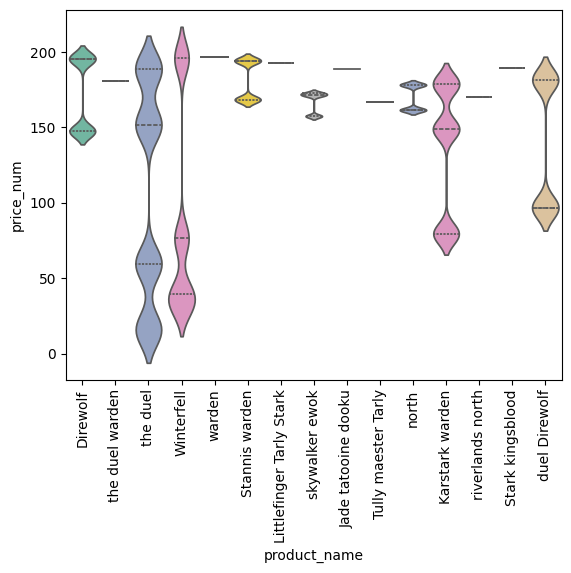

In [163]:
sns.violinplot(data=transactions_filtrado, x="product_name", y="price_num", palette="Set2", hue="product_name",
               inner="quartile",
               legend=False
               )
plt.xticks(rotation=90)

###**Conclusión:**

El top 15 de productos más vendidos tienen diferentes comportamientos:

. Unos productos con precio fijo, no tienen ningún tipo de variabilidad.

. Otros productos que tienen diferente dispersión de precios, lo que puede decir que, estos productos sufren de descuentos o negociaciones de precios para algunos clientes.

### Pregunta 4: Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris).


Se crean dos columnas con la hora de la compra y otra con el año de la compra.

In [164]:
transactions['hora'] = pd.to_datetime(transactions['timestamp']).dt.hour
transactions['año'] = pd.to_datetime(transactions['timestamp']).dt.year

Se hace una función que recibe como argumento la hora de la operacion y devuelve la franja horaria, así podemos agrupar las operación según la hora.

Se crea una nueva columna llamada franja aplicando la función que hemos creado previamente.

In [165]:
def franja(hora):
    if hora <= 5:
        return 'Madrugada'
    elif hora < 12:
        return 'Mañana'
    elif hora < 18:
        return 'Tarde'
    else:
        return 'Noche'

transactions['franja'] = transactions['hora'].apply(franja)


Para que el gráfico salga ordenado por la franja horaria y no alfabéticamente aplicamos la clase categorical para decirle como debe ordenar la columna.

In [166]:
transactions['franja'] = pd.Categorical(
    transactions['franja'],
    categories=['Madrugada', 'Mañana', 'Tarde', 'Noche'],
    ordered=True
)

Se hace una pivot_table que cuenta cuántas transacciones hay en cada combinación de franja horaria y año. El resultado es una tabla donde las filas son las franjas y las columnas son los años.

/tmp/ipykernel_18283/3422093027.py:5: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



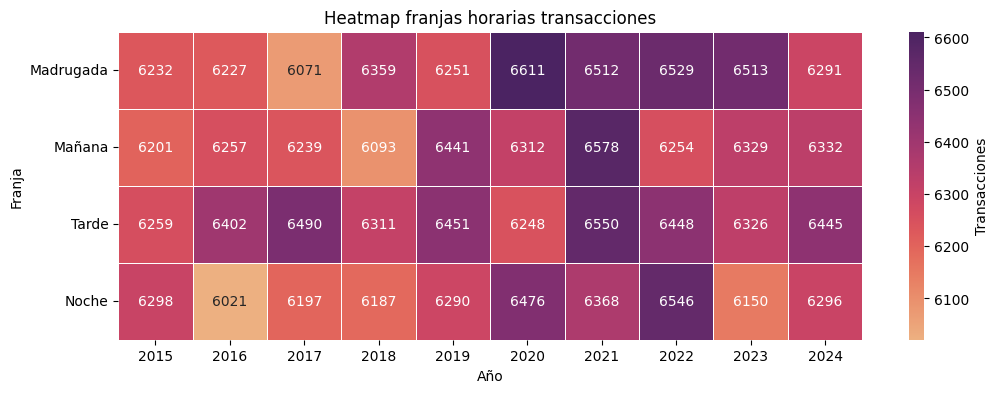

In [167]:
# Visualización
# He escogido el Heatmap porque es útil al tener una tabla con dos catefgoría.
# Además, el color ayuda a ver bien si hay picos de ventas, ayuda a comparar si hay patrones de venta.

franjas_op = transactions.pivot_table(
    values='hora',
    index='franja',
    columns='año',
    aggfunc='count'
)

plt.figure(figsize=(12, 4))
sns.heatmap(franjas_op, cmap='flare', annot=True, fmt='g', linewidths=.5, cbar_kws={'label': 'Transacciones'})
plt.title('Heatmap franjas horarias transacciones')
plt.xlabel('Año')
plt.ylabel('Franja')
plt.yticks(rotation=0)
plt.show()

### **Conclusión:**

No existe un patrón de horario de compra significativo, la actividad es bastante homogénea durante todas las horas del día. Se podría decir que los clientes tienen un comportamiento de compra bastante disperso.

## **NIVEL 2 - Anàlisi relacional i patrons avançats**

##Exercici 1: Anàlisi de productes i captació d'usuaris

Agrupamos todas las compras de cada cliente (user_id), después de todas las fechas de compra de cada cliente nos quedamos con la más antigua. ['fecha'].min(), nos quedamos con la más pequeña, es decir, la mas antigua.

Después se cambia el nombre de la columna para que no haya confusión con otra columna que se llama fecha.

In [168]:
fecha_min = transactions.groupby('user_id')['fecha'].min().reset_index()

fecha_min.columns = ['user_id', 'fecha_min']


Se une fecha más antigua al Dataframe principal.
Cada trasacción se queda con la fecha de la primera compra del usuario.

In [169]:
transactions = transactions.merge(fecha_min, on='user_id', how='left')


Se hace una función para comparar la fecha de la transacción con la fecha de la primera transacción del usuario.
Se crea una columna donde se aplica la función. Si coinciden nuevo_user == True

In [170]:
def nuevo_user(fecha_x, fecha_y):
    if fecha_x == fecha_y:
      return True
    else:
      return False

transactions['nuevo_user'] = transactions[['fecha', 'fecha_min']].apply(lambda row: nuevo_user(row['fecha'], row['fecha_min']), axis=1)



Se calcula métricas:
* Ingresos por producto, se suman los precios de cada producto.
* Variabilidad, miramos cuanto se alejan los precios de la media.

In [171]:
metricas = transactions.groupby('product_ids').agg({
    'price_num': ['sum', 'std']
})
metricas.columns = ['ingresos', 'variabilidad']
metricas = metricas.reset_index()

Agrupamos por producto y contamos cuantos usuarios distintos han comprado un producto.

In [172]:
total = transactions.groupby('product_ids')['user_id'].nunique().reset_index()
total.columns = ['product_ids', 'total_compradores']

Cuenta usuarios distintos por productos filtranbdo que estos usuarios sean nuevos usuarios.

In [173]:
nuevos = transactions[transactions['nuevo_user'] == True].groupby('product_ids')['user_id'].nunique().reset_index()


Une las tres tablas en un mismo DataFrame, usando product_ids como conector.

In [174]:
metricas = metricas.merge(total, on='product_ids').merge(nuevos.rename(columns={'user_id': 'nuevos_usuarios'}), on='product_ids')

Calcula el porcentaje de usuarios nuevos que han comprado el producto

In [175]:
metricas['porcent_nuevos'] = metricas['nuevos_usuarios'] / metricas['total_compradores'] * 100

Calculamos la mediana de ingresos y de captación como umbral de referencia.
Si un producto esta por encima o por debajo.

In [176]:
mediana_ingresos = metricas['ingresos'].median()
mediana_captacion = metricas['porcent_nuevos'].median()

Función que asigna la tipología según los cuatro cuadrantes:
* Captador:  altos ingresos + alta captación
* Recurrent: altos ingresos + baja captación
* Emergent:  bajos ingresos + alta captación
* Estancat:  bajos ingresos + baja captación

Aplicamos la función creando una columna nueva con la tipología.

In [177]:
def tipologia(producto):
    if producto['ingresos'] >= mediana_ingresos and producto['porcent_nuevos'] >= mediana_captacion:
      return 'Captador'
    elif  producto['ingresos'] >= mediana_ingresos and producto['porcent_nuevos'] < mediana_captacion:
      return 'Recurrent'
    elif producto['ingresos'] < mediana_ingresos and producto['porcent_nuevos'] >= mediana_captacion:
      return 'Emergent'
    else:
      return 'Estancat'

metricas['tipologia'] = metricas.apply(tipologia, axis=1)



Cada punto es un producto.

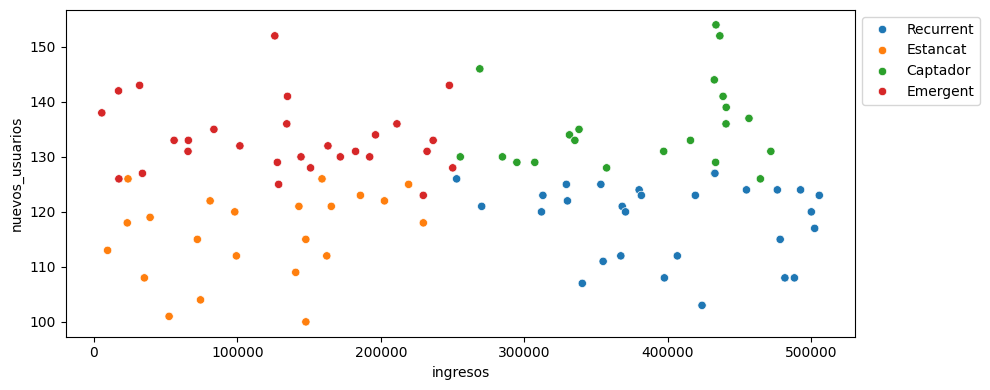

In [178]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=metricas, x="ingresos", y="nuevos_usuarios",
                hue="tipologia",
                size_norm="total_compradores")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **Conclusión:**

Con el gráfico podemos observar que:
- Recurrent: los productos recurrentas, a pesar de que no están captando muchos nuevos clientes, tienen altos ingresos.
- Estancat: sería la peor categoría, poca captación y pocos ingresos, habría que valorar por qué está ocurriendo.
- Captador: estos productos están captando nuevos clientes y además generan muchos ingresos.
- Emergent: los productos están captando nuevos clientes, pero no están aportando muchos ingresos. Habría que investigar si se están haciendo demasiados descuentos en estos productos o el precio es demasiado bajo...


##Exercici 2: Anàlisi geogràfica company–usuari i oportunitats d'expansió

### 1. Combina les taules necessàries.

La unión de usuarios europeos y americanos se hace directamente en BigQuery con UNION ALL, añadiendo la columna region dentro de la propia query.

El resultado llega ya fusionado como un único DataFrame, sin necesidad de pd.concat().


In [179]:
users = client.query("""
    SELECT *, 'EU' AS region FROM `sprint3-analytics-aherrezuelo.sprint3_bronze.european_users_raw`
    UNION ALL
    SELECT *, 'EUA' AS region FROM `sprint3-analytics-aherrezuelo.sprint3_bronze.american_users_raw`
""").to_dataframe()

Unimos transacciones+compranyes con usuarios.

In [180]:
datos = resultado.merge(users, left_on='user_id', right_on='id', how='left')

### 2. Crea una variable clau d'anàlisi: compra_local = True/False

Renombramos las columnas country de usuario y company para mayor claridad.

In [181]:
datos = datos.rename(columns={'country_x': 'country_company',
                              'country_y':'country_user'})

Se crea una columna con True/False su el país de la compañía es el mismo que el país del usuario.

In [182]:
datos['compra_local'] = datos['country_company'] == datos['country_user']

###3. Analitza el comportament global:

Con la variable frecuencia , se cuenta cuantas veces aparece cada valor para saber cuantos son compras locales y cuantos compras internacionales.

Con porcentaje, hacemos lo mismo pero lo convertimos a porcentaje. Que representa cada uno en la venta.


In [183]:
frecuencia = datos['compra_local'].value_counts()
porcentaje = datos['compra_local'].value_counts(normalize=True).mul(100).round(2)

resultado_local = pd.DataFrame({
    'Frecuencia': frecuencia,
    'Porcentaje (%)': porcentaje
})

resultado_local

,Frecuencia,Porcentaje (%)
compra_local,,
False,88138,88.14
True,11862,11.86


Se calcula la facturación según si es local o internacional.

También se calcula el porcentaje que representa cada uno.

In [184]:
facturacion_local = datos.groupby('compra_local')['amount'].sum().reset_index()

facturacion_local['porcentaje'] = (
    facturacion_local['amount']
    / facturacion_local['amount'].sum()
    * 100
).round(2)

facturacion_local

,compra_local,amount,porcentaje
0,False,22803963.14,88.04
1,True,3097568.03,11.96


###4. Anàlisi per país de l'usuari, per cada país d'usuari:

Agrupamos por país del usuario y calculamos la media de la compra local (% de compras locales) y la suma de facturación por países.

In [185]:
local_user = datos.groupby('country_user').agg({
    'compra_local': 'mean',
    'amount': 'sum'
})
local_user['compra_local'] = round(local_user['compra_local'] * 100,2)
local_user

,compra_local,amount
country_user,,
Canada,9.71,2584178.24
France,6.28,2175321.38
Germany,16.94,2265471.24
Italy,17.10,2238008.35
Netherlands,19.32,2316227.02
Poland,0.00,2141757.73
Portugal,0.00,2250608.19
Spain,1.74,2336623.33
Sweden,21.30,2089941.13


### 5. Anàlisi per país de companyia, per cada país de companyia calcula quina part de la seva facturació ve de:
### * Usuaris locals.
### * Usuaris estrangers.

Se calcula lo mismo que antes pero esta vez se agrupa por país de la compañía.

In [186]:
local_user = datos.groupby('country_company').agg({
    'compra_local': 'mean',
    'amount': 'sum'
})
local_user['compra_local'] = round(local_user['compra_local'] * 100,2)
local_user

,compra_local,amount
country_company,,
Australia,0.00,679418.68
Belgium,0.00,922131.39
Canada,46.04,542407.60
China,0.00,231218.79
France,11.36,1221902.17
Germany,11.12,3466842.93
Ireland,0.00,693054.42
Italy,10.72,3530071.81
Netherlands,11.50,3890755.90


###**Conclusión:**

- Australia, Belgium, China, Ireland, New Zealand, Norway → 0% de ventas locales, son compañías que venden exclusivamente a usuarios extranjeros.
- Canada → 46% y USA → 52% — los únicos con más del 40% de ventas locales.
- Sweden → 4,25M€ — el país con más facturación total pero solo 10% local.

###6. Escull una visualització que expliqui clarament el fenomen

In [187]:
px.choropleth(
    data_frame=local_user.reset_index(),
    locations='country_company',  # columna con nombres de países
    locationmode='country names',  # le dices que son nombres, no códigos
    color='amount',               # qué métrica colorea el mapa
    title='Facturación por país de compañía'
)

###**Conclusión:**

Depende de la estrategia que la empresa quiera desarrollar puede:
+ Invertir en mercado local en paises que hay facturación pero no desde compañía local. Por ejemplo, Poland, Portugal o Spain, quizás tener compañía local captaría más clientes.
+ Invertir en mercado local donde ya hay demanda en compañía local, eso reforzaría algo que ya funciona.

In [188]:
px.choropleth(
    data_frame=local_user.reset_index(),
    locations='country_company',
    locationmode='country names',
    color='compra_local',
    title='% venta local por país de compañía'
)

###**Conclusión:**

- USA y Canada son los mercados que hay ya un buen porcantaje de mercado local, ya tienen tracción local consolidada.

- Australia, Norway, China, Belgium, Ireland, New Zealand → 0% local pero sí tienen facturación, hay demanda pero sin oferta local que la capture.

- Europa central (Sweden, Netherlands, Germany, UK, Italy) → alta facturación pero solo ~10% local, puede ser un gran potencial de conversión si se abren compañías locales.

## **Nivell 3 - Visualització executiva i storytelling**

##Exercici 1: Mini-dashboard departamental

In [189]:
metricas

,product_ids,ingresos,variabilidad,total_compradores,nuevos_usuarios,porcent_nuevos,tipologia
0,1,397619.48,0.0,1901,108,5.681220,Recurrent
1,2,23774.52,0.0,1963,126,6.418747,Estancat
2,3,432616.64,0.0,1933,127,6.570098,Captador
3,4,185763.76,0.0,1956,123,6.288344,Estancat
4,5,436268.56,0.0,1943,152,7.822954,Captador
...,...,...,...,...,...,...,...
95,96,52425.52,0.0,1927,101,5.241308,Estancat
96,97,165474.00,0.0,1910,121,6.335079,Estancat
97,98,98201.46,0.0,1942,120,6.179197,Estancat
98,99,381574.92,0.0,1932,123,6.366460,Recurrent


/tmp/ipykernel_18283/1865848910.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_18283/1865848910.py:14: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



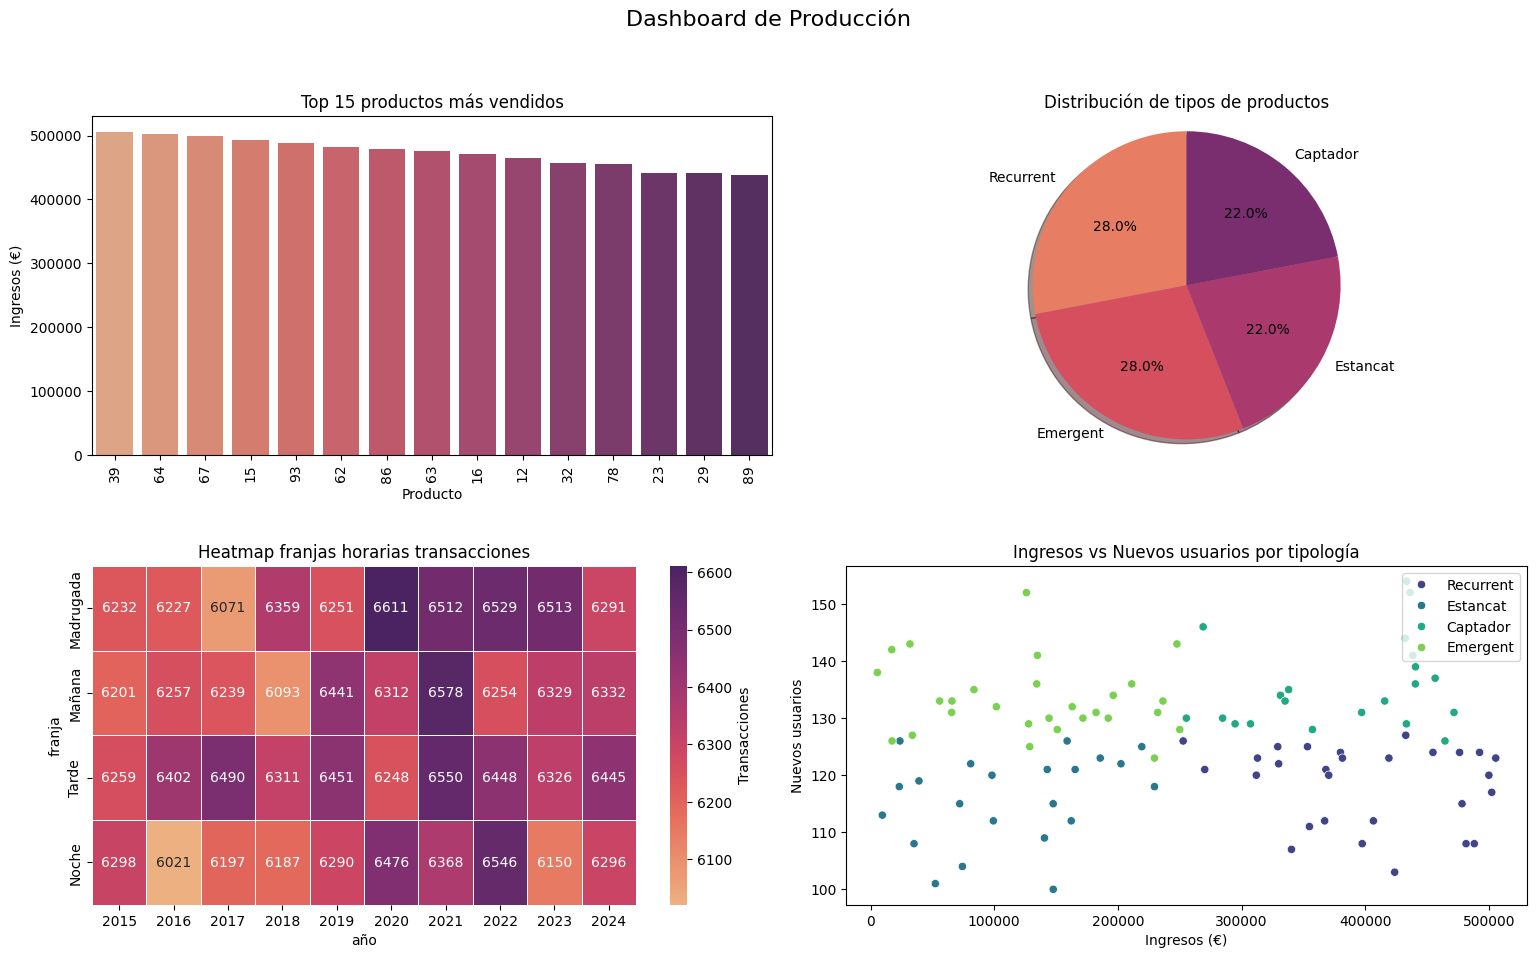

In [190]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Dashboard de Producción', fontsize=16)

# Gráfico 1 -----------
# TOP 15 productos más vendidos

top_productos = metricas.sort_values('ingresos', ascending=False).head(15)

sns.barplot(data=top_productos, x="product_ids", y="ingresos", order=top_productos.sort_values("ingresos", ascending=False).product_ids,
            palette="flare",
            legend=False,
            ax=axes[0, 0])

axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=90)
axes[0, 0].set_title('Top 15 productos más vendidos')
axes[0, 0].set_xlabel('Producto')
axes[0, 0].set_ylabel('Ingresos (€)')


# Gráfico 2 -----------
# Tipos de productos

valores_tipologia = metricas['tipologia'].value_counts()
colores = sns.color_palette('flare', len(valores_tipologia))

axes[0,1].pie(valores_tipologia, labels=valores_tipologia.index, autopct='%1.1f%%', shadow=True, startangle=90,
              colors=colores)
axes[0,1].axis('equal')
axes[0,1].set_title('Distribución de tipos de productos')


# Gráfico 3 -----------
# estacionalidad

sns.heatmap(franjas_op, cmap='flare', annot=True, fmt='g', linewidths=.5, cbar_kws={'label': 'Transacciones'}, ax=axes[1, 0])
axes[1, 0].set_title('Heatmap franjas horarias transacciones')
plt.tight_layout()

# Gráfico 4 -----------
# estacionalidad

sns.scatterplot(data=metricas, x="ingresos", y="nuevos_usuarios",
                hue="tipologia",
                palette="viridis",
                size_norm="total_compradores",
                ax=axes[1,1])
axes[1,1].legend(loc='upper right')
plt.tight_layout(pad=3.0)

axes[1,1].set_xlabel('Ingresos (€)')
axes[1,1].set_ylabel('Nuevos usuarios')
axes[1,1].set_title('Ingresos vs Nuevos usuarios por tipología')

plt.show()


# **INFORME**

Podemos observar tras ver los gráficos que, los ingresos por la venta del TOP 15 productos más vendidos es bastante igual para todos, por lo que, la compañía no depende sus ingresos de uno o pocos productos. Eso hace que en caso de que haya algun problema con suministros, problemas de almacenaje, que puedan afectar a la venta de alguno de los productos, no afectaría de manera grave a los ingresos.

También podemos deducir que la distribución en tipo de producto según como de asentado esté el producto, los ingresos que producen, etc; Aproximadamente un cuarto de esos productos estan estancados, habría que valorar su continuidad. Otro casi 25% son productos de tipo emergente, aunque estan teniendo buena captación no estan conseguiendo buenos ingresos, se debe revisar descuentos y precios.

Vemos que las transacciones sucenden de manera homogenea durante todos los meses del año, por lo que las ventas no tienen estacionalidad, debemos mantener almacenes cubiertos pero no es necesario invertir en campañas especificas de alguna temporada concreta.


# **INFORME IA**

### **Análisis de Ingresos por Productos**
Los ingresos generados por los 15 productos más vendidos muestran una distribución equitativa. Esta diversidad reduce la dependencia de productos individuales, mitigando el riesgo ante posibles problemas de suministro o almacenamiento que pudieran afectar a productos específicos. Se observa que aproximadamente el 25% de los productos se encuentran en una fase de estancamiento, requiriendo una evaluación de su continuidad. Otro 25% son productos emergentes con buena captación, pero bajos ingresos, lo que sugiere la necesidad de revisar sus estrategias de descuento y precios.

### **Estacionalidad y Patrones de Venta**
Las transacciones se distribuyen de manera homogénea a lo largo del año, indicando una ausencia de estacionalidad significativa en las ventas. Esta uniformidad en la demanda implica que no es necesario invertir en campañas estacionales específicas ni acumular stock adicional por motivos de temporada, aunque se debe mantener una cobertura adecuada de almacenes. Los patrones horarios de compra también son bastante dispersos, sin picos o valles significativos que sugieran un comportamiento de compra concentrado en franjas horarias específicas.